In [1]:
import opt_einsum as oe
import numpy as np
import torch
import sys
sys.path.append("../../")
import mps
from mps.trainer.data_utils import SyntheticDataset, SyntheticDatasetV2, SyntheticDatasetV3

import mps

In [ ]:
from mps import tpcp_mps
from mps import simple_mps
N = 100
batch_size = 2**12
dtype = torch.float64

# x0 = torch.randint(0, 2, (batch_size, N)).to(torch.float64)
# x0[:, 0] = 1

# x1 = x0.clone()
# x1[:, 1] = 0

# psi0 = torch.stack([x0, 1 - x0], dim=-1)
# psi1 = torch.stack([x1, 1 - x1], dim=-1)

# psi = torch.concat([psi0, psi1], dim=0)





Path is not set, setting...
Found the path
Initialized MPS with random matrices


In [117]:
target[2]

tensor(1)

In [128]:
data

tensor([[[1., 0.],
         [0., 1.],
         [1., 0.],
         [1., 0.],
         [1., 0.],
         [1., 0.],
         [1., 0.],
         [1., 0.],
         [1., 0.],
         [1., 0.]],

        [[1., 0.],
         [0., 1.],
         [1., 0.],
         [1., 0.],
         [1., 0.],
         [1., 0.],
         [1., 0.],
         [1., 0.],
         [1., 0.],
         [1., 0.]]], dtype=torch.float64)

In [130]:

from torch.utils.data import DataLoader
N = 1024
smps = simple_mps.SimpleMPS(
    N,
    d=2,
    chi=2,
    l=2,
    layers=1,
    eps = 0,
    dtype=dtype,
)
smps.train()


tpcp = tpcp_mps.MPSTPCP(
    N,
    K=1,
    d=2,
    enable_r=True,
    with_identity=False,
    manifold=tpcp_mps.ManifoldType.EXACT,
    dtype=dtype,
)

optimzier = torch.optim.SGD(tpcp.parameters(), lr=0.01)

tpcp.set_canonical_mps(smps)
# tpcp.train()
batch_size = 1024
for _ in range(100):
    target = torch.randint(0, 2, (batch_size, N)).to(dtype)
    data = torch.concat([target, 1 - target], dim=0)
    data[:, 0] = 1

    target = torch.tensor([1, 0]).to(dtype)

    optimzier.zero_grad()
    out, reg = tpcp(data,return_reg=True)
    tpcp.W.requires_grad = False
    tpcp.r.requires_grad = False
    delta_rho = tpcp.rho_last
    delta_rho = delta_rho[0] - delta_rho[1]

    loss = -torch.abs(delta_rho).mean()
    loss.backward()
    optimzier.step()
    print(loss.item())

Path is not set, setting...
Found the path
Initialized MPS with random matrices
-0.005271680124698079
-0.006716551871394395
-0.0087849286179848
-0.011625842590756004
-0.014987146268806727
-0.017898954843744742
-0.01968648400353209
-0.02083084489171215
-0.02183252580551649
-0.02283339608592694
-0.023857418646957198
-0.024908557560600567
-0.025988567204310503
-0.027099311414012624
-0.02824298339714352
-0.029422103881993095
-0.03063949858028911
-0.03189827255444207
-0.03320178445549813
-0.034553622717162086
-0.03595758549591758
-0.03741766577656354
-0.03893804266463024
-0.04052307950827458
-0.042177329162490014
-0.04390554644568784
-0.045712707651457074
-0.047604036866358945
-0.04958503880299414
-0.05166153787701429
-0.05383972332627032
-0.05612620027811843
-0.05852804680536144
-0.06105287716070749
-0.0637089115336421
-0.0665050528211723
-0.06945097103437003
-0.07255719606320925
-0.07583521957700338
-0.07929760682440984
-0.08295811898282338


KeyboardInterrupt: 

In [122]:
from torch.utils.data import DataLoader
batch_size = 1024
N = 1024
smps = simple_mps.SimpleMPS(
    N,
    d=2,
    chi=2,
    l=2,
    layers=1,
    eps = 0,
    dtype=dtype,
)
smps.train()


tpcp = tpcp_mps.MPSTPCP(
    N,
    K=1,
    d=2,
    enable_r=True,
    with_identity=False,
    manifold=tpcp_mps.ManifoldType.EXACT,
    dtype=dtype,
)

optimzier = torch.optim.SGD(tpcp.parameters(), lr=0.01)

tpcp.set_canonical_mps(smps)
# tpcp.train()
dataset = SyntheticDatasetV3(n=N, num_samples=2**15)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
for data, target in dataloader:
    data_flip = data.clone()
    data_flip[:, 0] = 1 - data[:, 0]
    target_flip = target.clone()
    target_flip = 1 - target
    data = torch.concat([data, data_flip], dim=0)
    target = torch.concat([target, target_flip], dim=0)

    optimzier.zero_grad()
    out, reg = tpcp(data,return_reg=True)
    tpcp.W.requires_grad = False
    tpcp.r.requires_grad = False
    delta_rho = tpcp.rho_last
    delta_rho = delta_rho[:batch_size] - delta_rho[batch_size:]

    loss = -torch.abs(delta_rho).mean()
    loss.backward()
    optimzier.step()
    print(loss.item())

Path is not set, setting...
Found the path
Initialized MPS with random matrices
-0.002841724972613993
-0.0027531734331110603
-0.0027358035654541897
-0.0028765869492492725
-0.0028201623031332956
-0.0028512473129561565
-0.0027220209373826527
-0.0028996842336251657


KeyboardInterrupt: 

In [15]:
from mps import tpcp_mps
import random

def get_metrics(N, runs, dtype, grad_i = 0):
    batch_size = 100
    x0 = torch.randint(0, 2, (batch_size, N)).to(torch.float64)
    x0[:, 0] = 1
    x1 = x0.clone()
    x1[:, 0] = 0
    psi0 = torch.stack([x0, 1 - x0], dim=-1)
    psi1 = torch.stack([x1, 1 - x1], dim=-1)
    psi = torch.concat([psi0, psi1], dim=0)


    delta_rho_list = []
    grad_list = []
    for run in range(runs):
        seed = run + N*100
        torch.manual_seed(seed)  
        np.random.seed(seed)
        random.seed(seed)
        tpcp = tpcp_mps.MPSTPCP(
            N,
            K=1,
            d=2,
            enable_r=True,
            with_identity=False,
            manifold=tpcp_mps.ManifoldType.EXACT,
            dtype=dtype,
        )
        tpcp.train()

        out, reg = tpcp(psi.to(dtype),return_reg=True)
        tpcp.W.requires_grad = False
        tpcp.r.requires_grad = False
        delta_rho = tpcp.rho_last
        delta_rho = delta_rho[:batch_size] - delta_rho[batch_size:]

        delta_rho_list.append(delta_rho)

        loss = torch.abs(delta_rho).mean()
        loss.backward()
        g = tpcp.kraus_ops.kraus_ops[grad_i].grad
        grad_list.append(g)
    
    # print(delta_rho_list[0].shape)
    # calculate the mean and variance of each element of delta_rho_list
    delta_rho_list = torch.stack(delta_rho_list, dim=0)
    mean_delta_rho = torch.mean(delta_rho_list, dim=0)
    var_delta_rho = torch.var(delta_rho_list, dim=0)

    grad_list = torch.stack(grad_list, dim=0)
    mean_grad = torch.mean(grad_list, dim=0)
    var_grad = torch.var(grad_list, dim=0)

    return mean_delta_rho, var_delta_rho, mean_grad, var_grad

In [16]:
import torch
import numpy as np
import random
import matplotlib.pyplot as plt
# Define parameters for the simulation
runs = 1000  # you can reduce this number for quicker tests
dtype = torch.complex128

# Lists to store N values and the corresponding mean variance
N_values = list(range(5, 13))
mean_variances = []
mean_grad_variances = []


for N in N_values:
    mean_delta_rho, var_delta_rho, mean_grad, var_grad = get_metrics(N, runs, dtype, -1)
    # Take the mean of the variance (averaging over all elements in delta_rho)
    mean_var = var_delta_rho.mean().item()
    mean_variances.append(mean_var)
    mean_grad_var = var_grad.mean().item()
    mean_grad_variances.append(mean_grad_var)
    print(f"N = {N}, Mean Variance = {mean_var}")


N = 5, Mean Variance = 0.012854177715636336
N = 6, Mean Variance = 0.005094865565461051
N = 7, Mean Variance = 0.0020618054398250287
N = 8, Mean Variance = 0.0008364133822361328
N = 9, Mean Variance = 0.00031415243204158783
N = 10, Mean Variance = 0.00012458600229992467
N = 11, Mean Variance = 5.2627019994381574e-05
N = 12, Mean Variance = 2.0796472296316093e-05


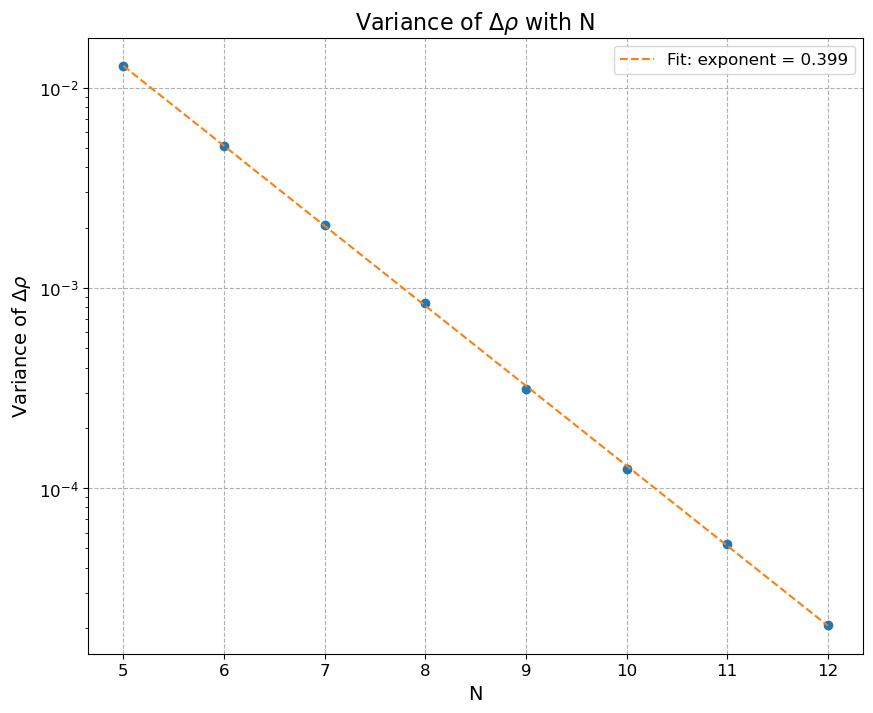

In [17]:
# Convert lists to numpy arrays for the fit
N_array = np.array(N_values)
mean_variances_array = np.array(mean_variances)

# Perform a linear regression on the logarithm of the mean variance
log_mean_variances = np.log(mean_variances_array)
coeffs = np.polyfit(N_array, log_mean_variances, 1)
slope, intercept = coeffs
fit_line = np.exp(intercept + slope * N_array)

# Plot the data and the fit with exponent in the legend
plt.figure(figsize=(10, 8))  # Increase the figure size
plt.plot(N_values, mean_variances, marker='o', linestyle='')
plt.plot(N_values, fit_line, linestyle='--', label=f'Fit: exponent = {np.exp(slope):.3f}')
plt.xlabel('N', fontsize=14)  # Increase font size
plt.ylabel('Variance of $\Delta \\rho$', fontsize=14)  # Increase font size
plt.yscale('log')
plt.title('Variance of $\Delta \\rho$ with N', fontsize=16)  # Increase font size
plt.grid(True, ls="--")  # Change grid to only show major ticks
plt.tick_params(axis='both', which='major', labelsize=12)  # Increase tick size
plt.legend(fontsize=12)  # Increase legend size
plt.show()

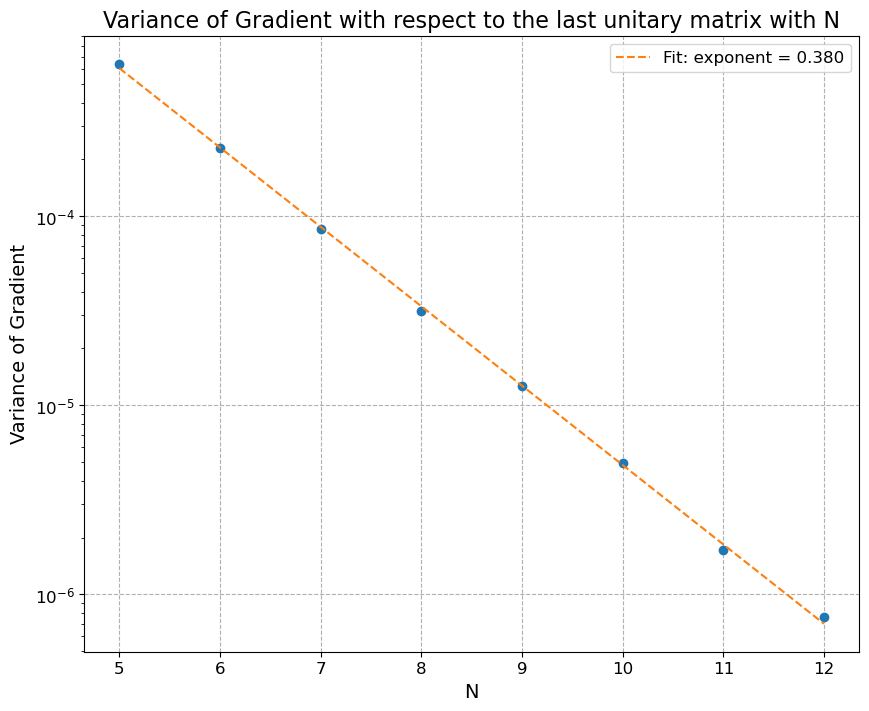

In [18]:
# Convert lists to numpy arrays for the fit
N_array = np.array(N_values)
mean_grad_variances_array = np.array(mean_grad_variances)

# Perform a linear regression on the logarithm of the mean gradient variance
log_mean_grad_variances = np.log(mean_grad_variances_array)
coeffs = np.polyfit(N_array, log_mean_grad_variances, 1)
slope, intercept = coeffs
fit_line = np.exp(intercept + slope * N_array)

# Plot the data and the fit with exponent in the legend
plt.figure(figsize=(10, 8))  # Increase the figure size
plt.plot(N_values, mean_grad_variances, marker='o', linestyle='')
plt.plot(N_values, fit_line, linestyle='--', label=f'Fit: exponent = {np.exp(slope):.3f}')
plt.xlabel('N', fontsize=14)  # Increase font size
plt.ylabel('Variance of Gradient', fontsize=14)  # Increase font size
plt.yscale('log')
plt.title('Variance of Gradient with respect to the last unitary matrix with N', fontsize=16)  # Increase font size
plt.grid(True, ls="--")  # Change grid to only show major ticks
plt.tick_params(axis='both', which='major', labelsize=12)  # Increase tick size
plt.legend(fontsize=12)  # Increase legend size
plt.show()

# Barren Plateau with NLL


In [3]:
N = 20
batch_size = 100
x0 = torch.randint(0, 2, (batch_size, N)).to(torch.float64)
x0[:, 0] = 1
x1 = x0.clone()
x1[:, 0] = 0
psi0 = torch.stack([x0, 1 - x0], dim=-1)
psi1 = torch.stack([x1, 1 - x1], dim=-1)
psi = torch.concat([psi0, psi1], dim=0)

In [29]:
from mps.trainer.utils import focal_loss
from mps.radam import RiemannianAdam
import geoopt
from mps import tpcp_mps


N = 30
batch_size = 1024
dtype = torch.complex128
lr = 0.05

x0 = torch.randint(0, 2, (batch_size, N)).to(torch.float64)
x0[:, 0] = 1
x1 = x0.clone()
x1[:, 0] = 0
psi0 = torch.stack([x0, 1 - x0], dim=-1)
psi1 = torch.stack([x1, 1 - x1], dim=-1)
psi = torch.concat([psi0, psi1], dim=0)


tpcp = tpcp_mps.MPSTPCP(
    N,
    K=1,
    d=2,
    enable_r=True,
    with_identity=False,
    manifold=tpcp_mps.ManifoldType.EXACT,
    dtype=dtype,
)
tpcp.train()

# optimizer = RiemannianAdam(tpcp.kraus_ops.parameters(), lr=lr)
optimizer = geoopt.optim.RiemannianSGD(tpcp.kraus_ops.parameters(), lr=lr)

res = {
    "grad_first": [],
    "grad_last": [],
    "loss_list": [],
}
for _ in range(1000):

    optimizer.zero_grad()
    out, reg = tpcp(psi.to(dtype),return_reg=True, return_probs=True)
    delta_rho = tpcp.rho_last
    delta_rho = delta_rho[:batch_size] - delta_rho[batch_size:]

    loss = -torch.abs(delta_rho).mean()
    loss.backward()
    # loss = focal_loss(out, psi[:, 0, 0])
    # loss.backward()
    print("loss", loss.item(), "iter", _)
    # calculate accuracy
    pred = torch.argmax(out, dim=-1)
    acc = (pred == psi[:, 0, 0]).float().mean()
    print("accuracy", acc.item())
    res["loss_list"].append(loss.item())
    res["grad_first"].append(torch.norm(tpcp.kraus_ops.kraus_ops[0].grad).item())
    res["grad_last"].append(torch.norm(tpcp.kraus_ops.kraus_ops[-1].grad).item())
    optimizer.step()

loss -2.533766304395874e-08 iter 0
accuracy 0.5
loss -2.5337665689423023e-08 iter 1
accuracy 0.5
loss -2.5337668337255216e-08 iter 2
accuracy 0.5
loss -2.533767098418069e-08 iter 3
accuracy 0.5
loss -2.5337673631021662e-08 iter 4
accuracy 0.5
loss -2.533767627561969e-08 iter 5
accuracy 0.5
loss -2.533767892430632e-08 iter 6
accuracy 0.5
loss -2.5337681570195256e-08 iter 7
accuracy 0.5
loss -2.5337684217529645e-08 iter 8
accuracy 0.5
loss -2.533768686346463e-08 iter 9
accuracy 0.5
loss -2.533768951447758e-08 iter 10
accuracy 0.5
loss -2.5337692156069033e-08 iter 11
accuracy 0.5
loss -2.53376948033385e-08 iter 12
accuracy 0.5
loss -2.533769745014586e-08 iter 13
accuracy 0.5
loss -2.5337700096920238e-08 iter 14
accuracy 0.5
loss -2.5337702743245804e-08 iter 15
accuracy 0.5
loss -2.5337705390459944e-08 iter 16
accuracy 0.5
loss -2.5337708038131912e-08 iter 17
accuracy 0.5
loss -2.5337710683861683e-08 iter 18
accuracy 0.5
loss -2.53377133282039e-08 iter 19
accuracy 0.5
loss -2.5337715979138

KeyboardInterrupt: 

In [28]:
delta_rho

tensor([[[ 0.6987-1.4923e-17j,  0.5976-3.9264e-01j],
         [ 0.5976+3.9264e-01j, -0.6987+1.4923e-17j]],

        [[ 0.7016+3.8317e-17j, -0.6128+3.6259e-01j],
         [-0.6128-3.6259e-01j, -0.7016-3.8317e-17j]],

        [[ 0.7104-1.2710e-17j,  0.6604-2.4251e-01j],
         [ 0.6604+2.4251e-01j, -0.7104+1.2710e-17j]],

        ...,

        [[ 0.7186-9.4432e-17j, -0.6543+2.3346e-01j],
         [-0.6543-2.3346e-01j, -0.7186+9.4432e-17j]],

        [[ 0.7097-4.3647e-17j,  0.5892-3.8577e-01j],
         [ 0.5892+3.8577e-01j, -0.7097+4.3647e-17j]],

        [[-0.6973-1.4197e-17j, -0.5499+4.5909e-01j],
         [-0.5499-4.5909e-01j,  0.6973+1.4197e-17j]]], dtype=torch.complex128,
       grad_fn=<SubBackward0>)

In [15]:
out, reg = tpcp(psi.to(dtype),return_reg=True, return_probs=True)
loss = focal_loss(out, psi[:, 0, 0])

# calculate accuracy
pred = torch.argmax(out, dim=-1)
acc = (pred == psi[:, 0, 0]).float().mean()
print("accuracy", acc.item())


accuracy 0.68359375


In [14]:
out

tensor([[0.4572, 0.5428],
        [0.4425, 0.5575],
        [0.4321, 0.5679],
        ...,
        [0.4435, 0.5565],
        [0.4352, 0.5648],
        [0.2534, 0.7466]], dtype=torch.float64, grad_fn=<DivBackward0>)

In [122]:
import random
N = 10
batch_size = 1024
res_list = []
for _ in range(100):
    seed = random.randint(0, 1000000)
    print(seed)
    torch.manual_seed(seed)
    np.random.seed(seed)
    res = grad_NLL(N, batch_size, dtype)
    res_list.append(res)

718879
loss 0.3500365614154829 iter 0
loss 0.34967479995425194 iter 1
loss 0.3493783592987355 iter 2
loss 0.34912915531448285 iter 3
loss 0.3489159361034119 iter 4
loss 0.3487312340565142 iter 5
loss 0.3485697788201203 iter 6
loss 0.34842765100271844 iter 7
loss 0.34830181489957407 iter 8
loss 0.3481898483452488 iter 9
loss 0.34808977768612515 iter 10
loss 0.3479999707992756 iter 11
loss 0.3479190636390569 iter 12
loss 0.3478459072070881 iter 13
loss 0.34777952769312614 iter 14
loss 0.34771909559199976 iter 15
loss 0.3476639012421444 iter 16
loss 0.34761333514253717 iter 17
loss 0.3475668719334811 iter 18
loss 0.34752405724908 iter 19
loss 0.34748449685651683 iter 20
loss 0.34744784763745407 iter 21
loss 0.3474138100660642 iter 22
loss 0.3473821219110035 iter 23
loss 0.3473525529436087 iter 24
loss 0.347324900476991 iter 25
loss 0.34729898559390937 iter 26
loss 0.34727464994760815 iter 27
loss 0.347251753040827 iter 28
loss 0.3472301699050943 iter 29
loss 0.3472097891160832 iter 30
los

KeyboardInterrupt: 

In [107]:
import pandas as pd

# Create dataframes: each column is one run's data and each row is an epoch.
loss_df = pd.DataFrame({f'run_{i+1}': res['loss_list'] for i, res in enumerate(res_list)})
grad_first_df = pd.DataFrame({f'run_{i+1}': res['grad_first'] for i, res in enumerate(res_list)})
grad_last_df = pd.DataFrame({f'run_{i+1}': res['grad_last'] for i, res in enumerate(res_list)})



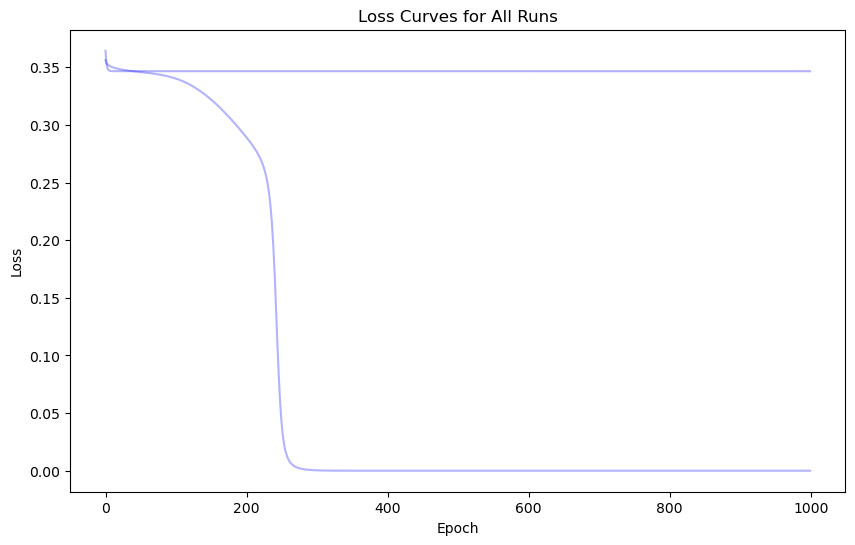

In [110]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for col in loss_df.columns:
    plt.plot(loss_df.index, loss_df[col], color='blue', alpha=0.3)  # All curves in blue with transparency
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves for All Runs')
plt.show()
